#Tarefa 1 — Classificação (ANEEL)

Preparando o ambiente

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Separação de dados treino e teste e machine learning




In [94]:
from sklearn.model_selection import train_test_split
#X_train, X_test, Y_train, Y_test

#Métrica para classificação
from sklearn.metrics import accuracy_score #acurácia
from sklearn.metrics import confusion_matrix #identificação de onde o modelo errou
from sklearn.metrics import classification_report #resumo de métricas
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

carregando os dados

In [95]:
dados = pd.read_csv('https://raw.githubusercontent.com/Enzopeter/Checkpoint_02_SolucoesEmEnergia/refs/heads/main/aneel_classificacao_orange.csv')

In [96]:
dados.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [97]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [98]:
dados.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [99]:
dados.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


Criando um DataFrame e separando os dados


In [100]:
#Separando os dados de fonte da potencia, latitude e longitude
#Feature = X
X = dados[['potencia_kw', 'latitude', 'longitude']]
#Target = Y
y = dados['fonte']

Separando os dados de treino e teste

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

Distribuição de classes

In [102]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64
fonte
Hidráulica    38.080495
Solar         30.959752
Eólica        30.959752
Name: proportion, dtype: float64


#Treinando os modelos

KNN

In [103]:
# Padronização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criar o modelo
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

#previsão
y_pred_knn = knn.predict(X_test_scaled)

Árvore de Decisão

In [104]:
# Criar o modelo
arvore = DecisionTreeClassifier(random_state=20)

arvore.fit(X_train, y_train)

#previsão
y_pred_arvore = arvore.predict(X_test)

Random Forest

In [105]:
# Criar o modelo
floresta = RandomForestClassifier(n_estimators=100,random_state=20)

floresta.fit(X_train, y_train)

#previsão
y_pred_floresta = floresta.predict(X_test)

Comparação entre os modelos. Utilizando o weighted

In [106]:
resultados = pd.DataFrame({
    'Modelo': ['KNN', 'Árvore de Decisão', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_arvore),
        accuracy_score(y_test, y_pred_floresta)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_arvore, average='weighted'),
        precision_score(y_test, y_pred_floresta, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_arvore, average='weighted'),
        recall_score(y_test, y_pred_floresta, average='weighted')
    ],
    'F1': [
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_arvore, average='weighted'),
        f1_score(y_test, y_pred_floresta, average='weighted')
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1
0,KNN,0.958763,0.958999,0.958763,0.958724
1,Árvore de Decisão,0.966495,0.966546,0.966495,0.966499
2,Random Forest,0.975515,0.975721,0.975515,0.975425


Matriz de confusão

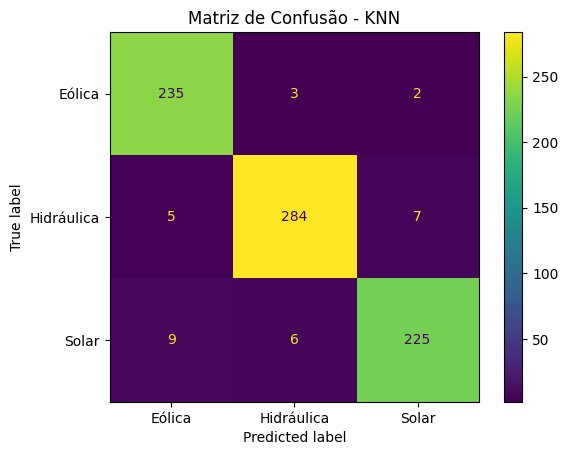

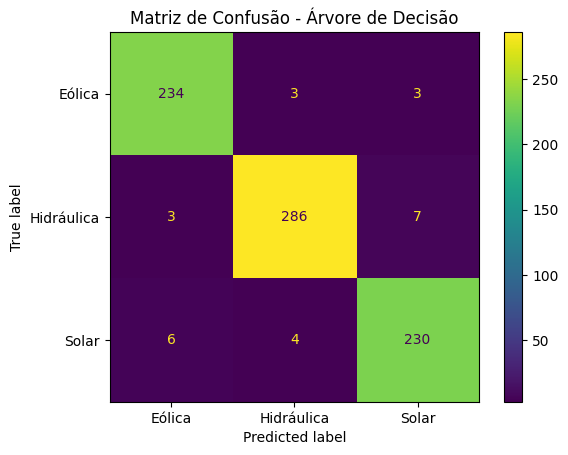

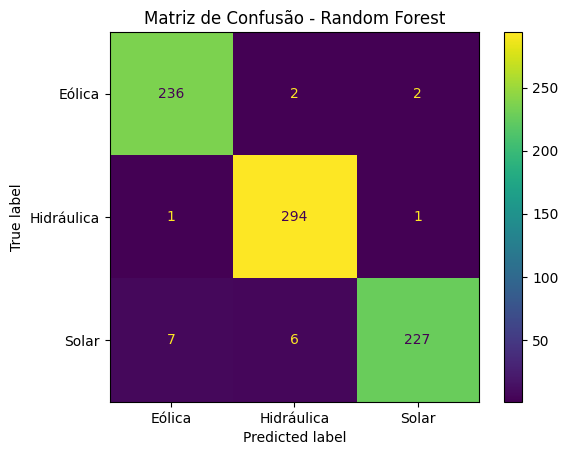

In [107]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("Matriz de Confusão - KNN")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arvore)
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_floresta)
plt.title("Matriz de Confusão - Random Forest")
plt.show()

#Análise Escrita

### Análise dos resultados

Foram utilizados três classificadores distintos para prever a fonte de geração (`Solar`, `Eólica` e `Hidráulica`) a partir das variáveis `potencia_kw`, `latitude` e `longitude`. Os dados foram divididos em 80% para treinamento e 20% para teste, utilizando estratificação e `random_state=20`, garantindo que os três modelos fossem avaliados sobre as mesmas divisões dos dados.

Para o KNN, foi realizada padronização das variáveis utilizando `StandardScaler`. O ajuste do scaler foi feito somente sobre os dados de treinamento e, posteriormente, a mesma transformação foi aplicada aos dados de teste. A Árvore de Decisão e o Random Forest foram treinados sem padronização.

As métricas foram calculadas utilizando a média ponderada (`weighted`) para Precision, Recall e F1, considerando a quantidade de exemplos de cada classe. Os resultados obtidos foram:

* **KNN:** Accuracy = 0,9588; Precision = 0,9590; Recall = 0,9588; F1 = 0,9587.
* **Árvore de Decisão:** Accuracy = 0,9665; Precision = 0,9665; Recall = 0,9665; F1 = 0,9665.
* **Random Forest:** Accuracy = 0,9755; Precision = 0,9757; Recall = 0,9755; F1 = 0,9754.

As matrizes de confusão permitem observar quais classes foram classificadas corretamente e quais foram confundidas pelos modelos. Os erros de classificação representam principalmente casos em que as características de potência e localização de um empreendimento são semelhantes às características encontradas em empreendimentos de outra fonte. Dessa forma, a análise da matriz de confusão deve ser utilizada para identificar quais pares de classes apresentam maior quantidade de erros.

Os resultados mostram que os três modelos conseguiram realizar a classificação com métricas elevadas no conjunto de teste, embora apresentem diferenças entre si. O Random Forest apresentou as métricas calculadas mais altas entre os modelos avaliados neste conjunto de dados, seguido pela Árvore de Decisão e pelo KNN.

Apesar dos resultados, existem limitações importantes. A classificação utiliza somente potência instalada/outorgada, latitude e longitude como variáveis de entrada. Essas informações podem apresentar padrões relacionados à fonte de geração, mas não descrevem diretamente todas as características técnicas de um empreendimento. Além disso, a coluna `potencia_kw` representa a potência outorgada em quilowatts e não a quantidade de energia efetivamente produzida. Portanto, os resultados não devem ser interpretados como uma previsão da geração de energia, mas apenas como uma classificação da fonte cadastrada no conjunto de dados.

Outra limitação é que o cadastro contém empreendimentos em diferentes fases, portanto a classificação está relacionada aos registros presentes na base e não necessariamente a empreendimentos efetivamente em operação. Assim, embora os modelos apresentem bom desempenho no conjunto de teste utilizado, a capacidade de generalização para outros dados ou para empreendimentos com características diferentes pode ser limitada.
